In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df=pd.read_excel("/content/MEMR-Raw Data-July.xlsx", skiprows=2)

df.head()

,Date and Time,Unnamed: 1,FPE.Meteo01.sensor_row_a17.Irradiation,FPE.Meteo01.sensor_row_b22.Irradiation,FPE.Meteo01.sensor_row_b24.Irradiation,FPE.Meteo02.sensor_row_a05.Irradiation,FPE.Meteo02.sensor_row_a06.Irradiation,FPE.Meteo02.sensor_row_b11.Irradiation,Unnamed: 8,Power.Analyzer_Schneider_ION.Active Power Total,...,Unnamed: 12,Inverter.01.AC_active_power,Inverter.02.AC_active_power,Inverter.03.AC_active_power,When Max Solar Irradiance is higher than 1,Unnamed: 17,Unnamed: 18,Inverters down time,Unnamed: 20,Unnamed: 21
0,NaN,NaN,[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],Irradiation Tilted (kWh/m2),NaN,...,Average Module Temp (C°),[kW],[kW],[kW],Inverter 1 useful time,Inverter 2 useful time,Inverter 3 useful time,Inverter 1 down time,Inverter 2 down time,Inverter 3 down time
1,01.07.2020 00:00:00,NaN,0.5,0,0,0.2,0.5,0.2,0,25.683,...,NaN,0,0,0,0,0,0,0.99992,0.99992,0.99992
2,01.07.2020 00:01:00,NaN,0.4,0,0.1,0.2,0.5,0.2,0,26.633,...,,0,0,0,0,0,0,NaN,NaN,NaN
3,01.07.2020 00:02:00,NaN,0.4,0,0,0.1,0.5,0.2,0,26.400,...,,0,0,0,0,0,0,NaN,NaN,NaN
4,01.07.2020 00:03:00,NaN,0.4,0,0.1,0.2,0.5,0.2,0,26.000,...,,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
power_cols = [
    'Inverter.01.AC_active_power',
    'Inverter.02.AC_active_power',
    'Inverter.03.AC_active_power'
]

In [ ]:
irr_cols = [col for col in df.columns if 'Irradiation' in col]

In [ ]:
for col in power_cols + irr_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df['Max_Solar_Irradiance'] = df[irr_cols].max(axis=1)

In [ ]:
df_useful = df[df['Max_Solar_Irradiance'] > 1].copy()

In [ ]:
print(f"the cleaned data : {len(df_useful)} daylight minutes identified")

the cleaned data : 27167 daylight minutes identified


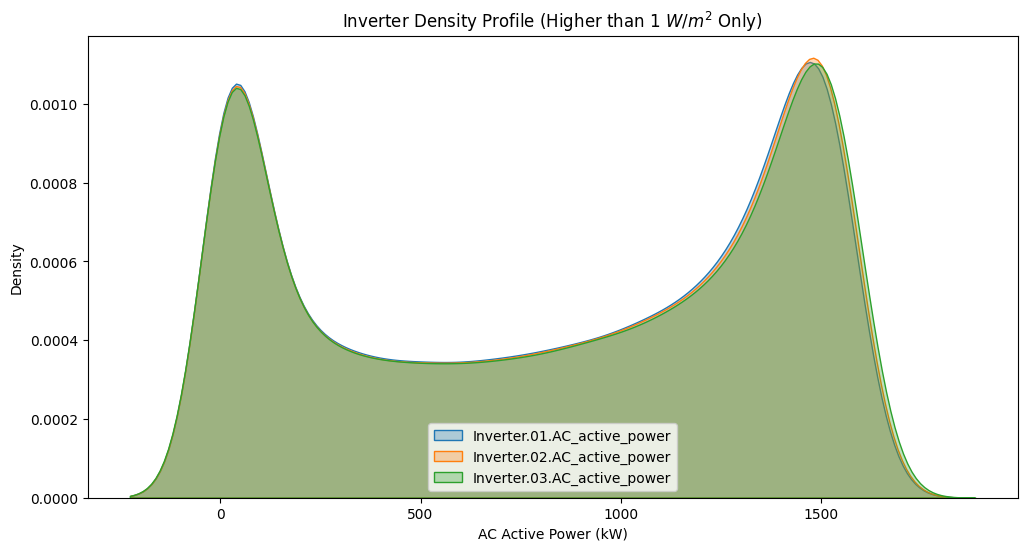

In [ ]:
plt.figure(figsize=(12, 6))
for col in power_cols:
    sns.kdeplot(df_useful[col], label=col, fill=True, alpha=0.3)
plt.title("Inverter Density Profile (Higher than 1 $W/m^2$ Only)")
plt.xlabel("AC Active Power (kW)")
plt.ylabel("Density")
plt.legend()
plt.show()

#high behavioral symmetry cause they overlap, inverters 1 2 3 are receiving similar solar fuel and converting it with identical efficiency

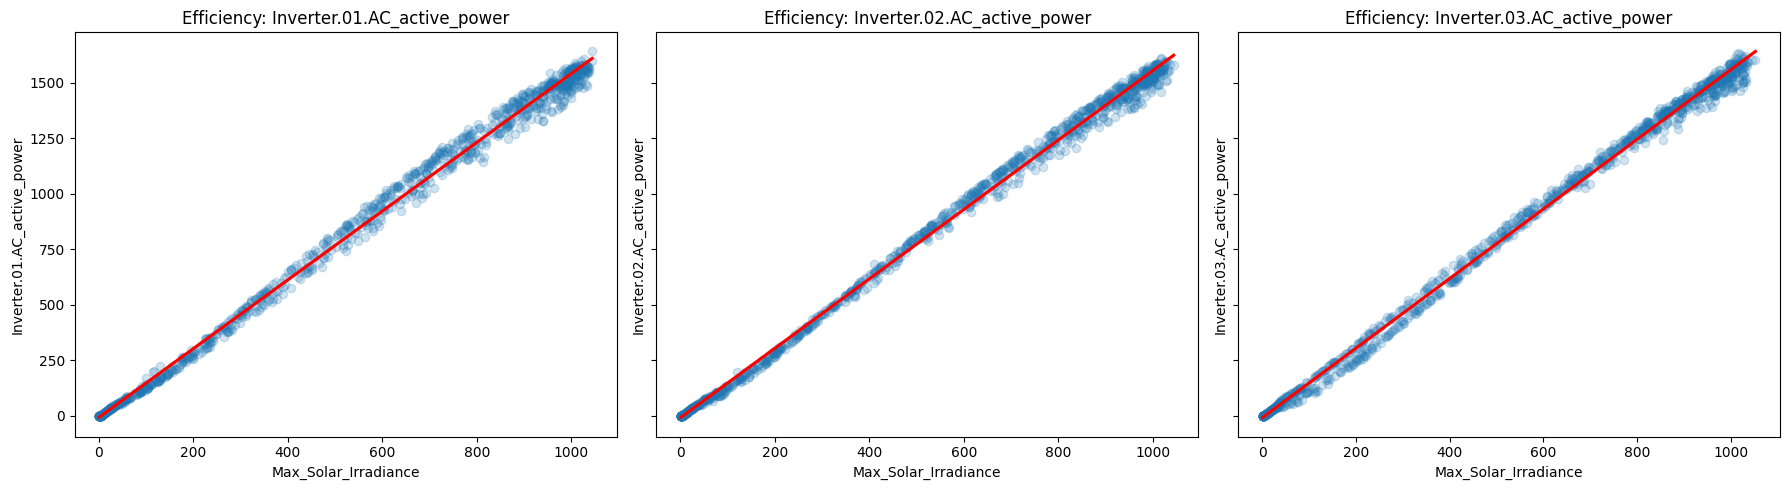

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, col in enumerate(power_cols):
    sns.regplot(x='Max_Solar_Irradiance', y=col, data=df_useful.sample(1000),
                ax=axes[i], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
    axes[i].set_title(f"Efficiency: {col}")
plt.tight_layout()
plt.show()

#nearly perfect linear relationship, inverters are tracking the maximum power point (MPP) effectively as sunlight intensity changes throughout the day
#inverters are synchronized
#the system utilizes its full capacity
#no power clipping, graph is connected and cont
#negative skewness, the tail stretches downwards, means when the system is at high power, it has a long and consistent up phase

In [ ]:
stats = df_useful[power_cols].describe().T
stats['Skewness'] = df_useful[power_cols].skew()
stats['Kurtosis'] = df_useful[power_cols].kurtosis()
print(stats[['mean', 'std', 'max', 'Skewness', 'Kurtosis']])

#the mean values across inverters are within 1% of each other, means excellent load balancing n identical string health across the site
#inverter 3 reached the highest peak $1,661.7, likely due to a slightly more efficient DC string configuration or lower local operating temperatures
#slight negative skewness indicates that the system spends more time operating at the higher end of its power capacity (typical for july)

                                   mean         std     max  Skewness  \
Inverter.01.AC_active_power  823.955064  566.086290  1651.0 -0.187339   
Inverter.02.AC_active_power  828.885606  568.305418  1647.9 -0.192728   
Inverter.03.AC_active_power  832.520574  571.492268  1661.7 -0.190532   

                             Kurtosis  
Inverter.01.AC_active_power -1.515898  
Inverter.02.AC_active_power -1.515291  
Inverter.03.AC_active_power -1.515449  


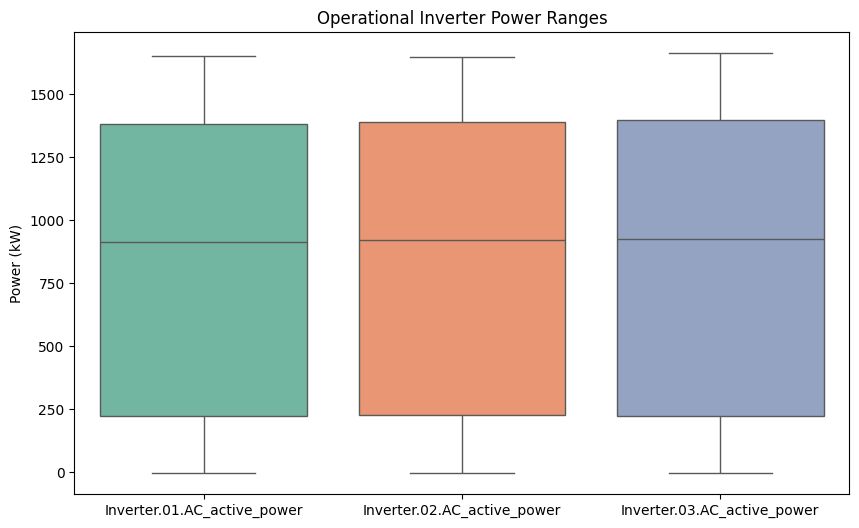

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_useful[power_cols], palette="Set2")
plt.title("Operational Inverter Power Ranges")
plt.ylabel("Power (kW)")
plt.savefig('boxplot_exploration.png')

#the median is roughly around 920 kW
#inverters are perfectly balanced and performing with the same efficiency across the plant
#long whiskers demonstrate the high variability of solar energy
#theres no performance lag, theyre kinda perfectly aligned

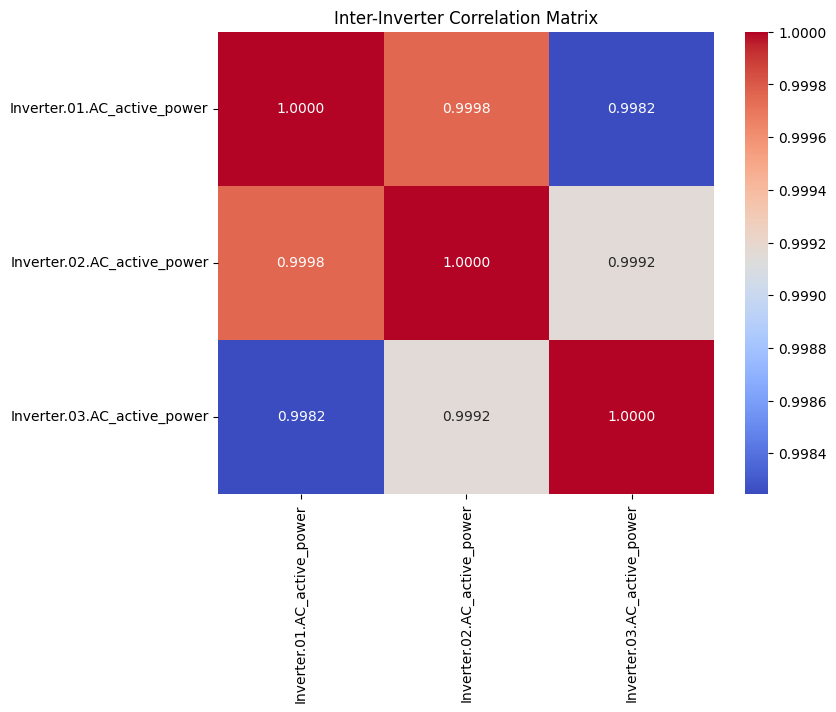

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_useful[power_cols].corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title("Inter-Inverter Correlation Matrix")
plt.savefig('heatmap_exploration.png')


#there is no localized technical failure meaning that
#if one inverter was shaded by a tree or had a failing internal component its correlation value with the others would drop

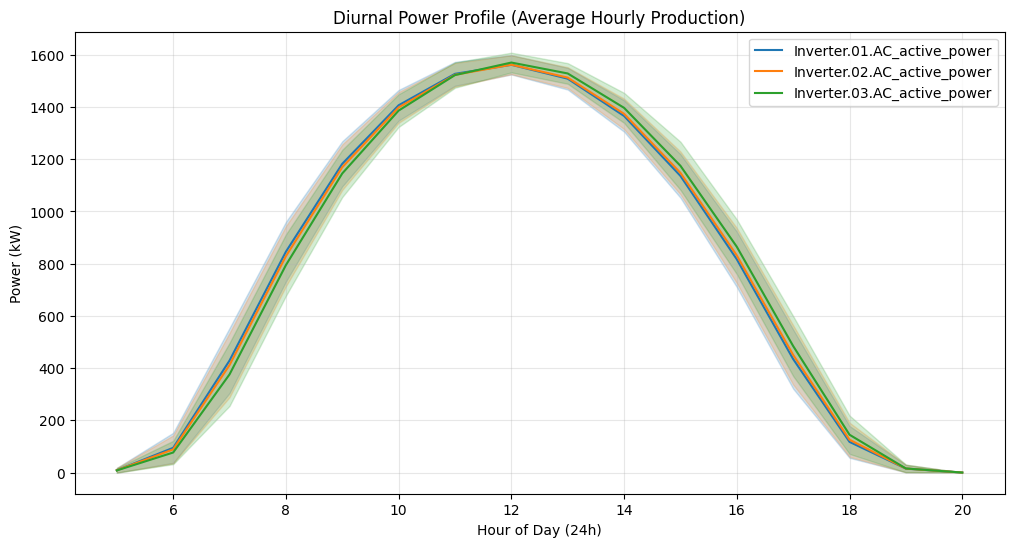

In [ ]:
df_useful['DateTime'] = pd.to_datetime(df_useful['Date and Time'], errors='coerce')
df_useful['Hour'] = df_useful['DateTime'].dt.hour

plt.figure(figsize=(12, 6))
for col in power_cols:
    sns.lineplot(data=df_useful, x='Hour', y=col, label=col)
plt.title("Diurnal Power Profile (Average Hourly Production)")
plt.ylabel("Power (kW)")
plt.xlabel("Hour of Day (24h)")
plt.grid(True, alpha=0.3)
plt.show()

#bell curve means it tracks the suns trajectory perfectly throughout the month
#golden hoours are between 10 and 25
#more demonstration of a balanced system (100th time)

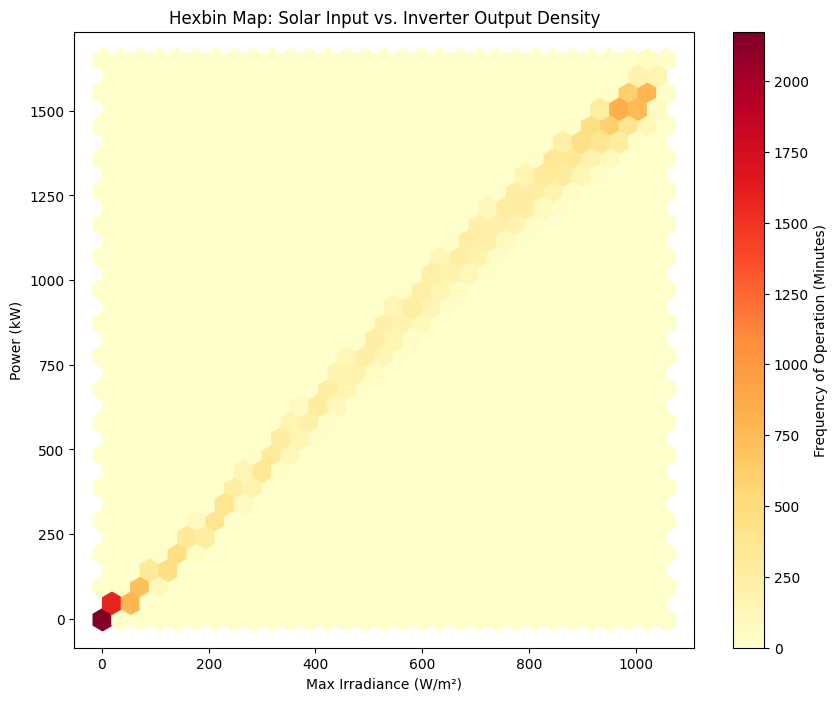

In [ ]:
plt.figure(figsize=(10, 8))
plt.hexbin(df_useful['Max_Solar_Irradiance'], df_useful[power_cols[0]], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Frequency of Operation (Minutes)')
plt.title("Hexbin Map: Solar Input vs. Inverter Output Density")
plt.xlabel("Max Irradiance (W/m²)")
plt.ylabel("Power (kW)")
plt.show()

#straught line shows the system is efficient
#system is stable cause theres not outliers

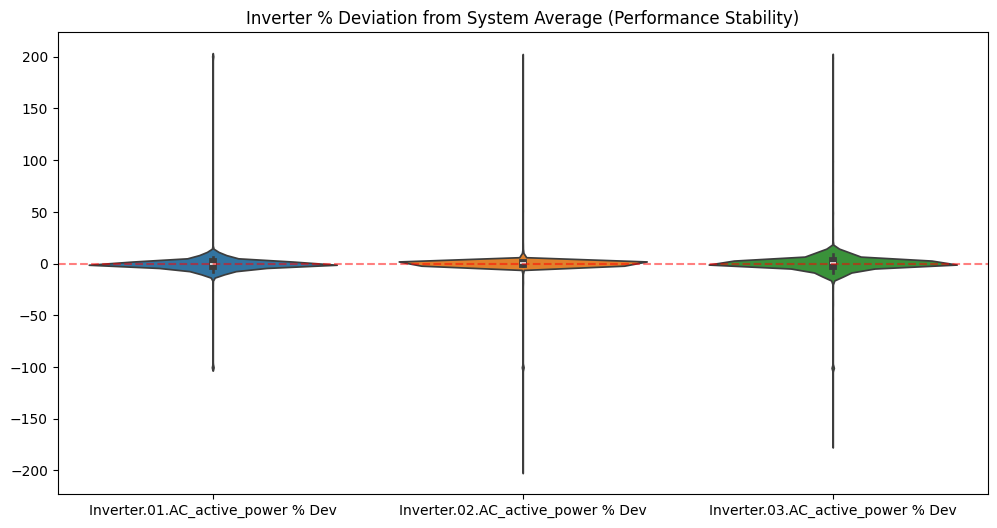

In [ ]:
df_useful['System_Mean'] = df_useful[power_cols].mean(axis=1)
dev_data = pd.DataFrame()
for col in power_cols:
    dev_data[f'{col} % Dev'] = ((df_useful[col] - df_useful['System_Mean']) / df_useful['System_Mean']) * 100

plt.figure(figsize=(12, 6))
sns.violinplot(data=dev_data.replace([np.inf, -np.inf], np.nan).dropna())
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Inverter % Deviation from System Average (Performance Stability)")
plt.show()


#violins are straight and skinny, means the system is stabke
#inverter 3 is the strongest performer but not by alot